# Końcowa ocena odporności ResNet50 na zmienne warunki oświetleniowe

Celem eksperymentu jest końcowa ocena odporności modeli `ResNet50` na kontrolowane zmiany warunków oświetleniowych na niezależnym zbiorze `test_final`.

Porównywane są dwie wcześniej określone konfiguracje:

- ResNet50 uczony na obrazach bez dodatkowego preprocessingu,
- ResNet50 uczony z zastosowaniem korekcji gamma γ = 1.5.

Obie konfiguracje są oceniane dla:

- obrazu oryginalnego,
- umiarkowanego zaciemnienia (`dark_1`),
- silniejszego zaciemnienia (`dark_2`),
- silnego zaciemnienia (`dark_3`).

Zmiana warunków oświetleniowych jest wykonywana przed zastosowaniem preprocessingu, dzięki czemu badany jest cały łańcuch przetwarzania obrazu.

Wyniki zbioru `test_final` nie są wykorzystywane do wyboru modelu, wartości parametru gamma ani pozostałych ustawień eksperymentu.

In [ ]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report

PROJECT_ROOT = Path(
    r"C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska"
)


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


from src.data.lighting_augmentation import (
    ControlledLightingDataset,
    LIGHTING_FACTORS,
)

from src.data.preprocessing import (
    build_preprocessing_eval_transform,
)

from src.models.resnet50 import (
    create_resnet50,
)

from src.evaluation.metrics import (
    predict,
    evaluate_predictions,
)

from src.utils.seed import (
    set_seed,
)


set_seed(42)


METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "data"
    / "processed"
    / "metadata"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)

REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "final_lighting_test"
)

FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
)

CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)


for directory in [
    METRICS_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Urządzenie:",
    DEVICE
)

Urządzenie: cpu


## 1. Konfiguracja końcowego eksperymentu

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
GAMMA = 1.5

CONFIGURATIONS = [
    {
        "name": "original",
        "method": "original",
        "gamma": None,
        "checkpoint": (
            CHECKPOINT_DIR
            / "resnet50_original_finetuned_best.pt"
        ),
    },

    {
        "name": "gamma_1.5",
        "method": "gamma",
        "gamma": GAMMA,
        "checkpoint": (
            CHECKPOINT_DIR
            / "resnet50_gamma_1.5_finetuned_best.pt"
        ),
    },
]


LIGHTING_VARIANTS = [
    "original",
    "dark_1",
    "dark_2",
    "dark_3",
]


print(
    "Konfiguracje:"
)

for configuration in CONFIGURATIONS:

    print(
        configuration["name"],
        "→",
        configuration["checkpoint"]
    )

Konfiguracje:
original → C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska\models\checkpoints\resnet50_original_finetuned_best.pt
gamma_1.5 → C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska\models\checkpoints\resnet50_gamma_1.5_finetuned_best.pt


## 2. Manifest zbioru testowego i mapowanie klas


In [3]:
TRAIN_PATH = (
    METADATA_DIR
    / "07_train.csv"
)

VALIDATION_PATH = (
    METADATA_DIR
    / "08_validation.csv"
)

TEST_PATH = (
    METADATA_DIR
    / "09_test_final.csv"
)


train_df = pd.read_csv(
    TRAIN_PATH
)

validation_df = pd.read_csv(
    VALIDATION_PATH
)

test_df = pd.read_csv(
    TEST_PATH
)


class_codes = sorted(
    set(
        train_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        validation_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        test_df[
            "class_code"
        ].astype(str)
    )
)


class_to_idx = {
    class_code: index
    for index, class_code
    in enumerate(class_codes)
}


idx_to_class = {
    index: class_code
    for class_code, index
    in class_to_idx.items()
}


print(
    "Liczba klas:",
    len(class_codes)
)

print(
    "TEST_FINAL:",
    len(test_df)
)

Liczba klas: 92
TEST_FINAL: 4298


## 3. Kontrola dostępności checkpointów

Do końcowego porównania wykorzystywane są checkpointy modeli uzyskanych w notebooku 08 po treningu z 10 epokami przy zamrożonym backbone oraz 5 epokami fine-tuningu.

In [4]:
for configuration in CONFIGURATIONS:

    checkpoint = (
        configuration[
            "checkpoint"
        ]
    )

    print(
        configuration[
            "name"
        ],
        "->",
        checkpoint,
        "| exists:",
        checkpoint.exists(),
    )


missing_checkpoints = [
    configuration[
        "name"
    ]
    for configuration
    in CONFIGURATIONS
    if not configuration[
        "checkpoint"
    ].exists()
]


if missing_checkpoints:

    raise FileNotFoundError(
        "Brak checkpointów: "
        f"{missing_checkpoints}"
    )


print(
    "\nWszystkie checkpointy są dostępne."
)

original -> C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska\models\checkpoints\resnet50_original_finetuned_best.pt | exists: True
gamma_1.5 -> C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska\models\checkpoints\resnet50_gamma_1.5_finetuned_best.pt | exists: True

Wszystkie checkpointy są dostępne.


## 4. Funkcja wczytywania modelu

In [5]:
def load_model(
    configuration,
):

    model = create_resnet50(
        num_classes=len(
            class_codes
        ),
        pretrained=False,
    )


    state_dict = torch.load(
        configuration[
            "checkpoint"
        ],
        map_location=DEVICE,
    )


    model.load_state_dict(
        state_dict
    )


    model = model.to(
        DEVICE
    )

    model.eval()


    return model

## 5. Funkcja oceny modelu dla określonego warunku oświetleniowego

Wariant oświetleniowy jest modyfikowany przed zastosowaniem preprocessingu. Oznacza to, że dla konfiguracji Gamma kolejność jest następująca:

obraz oryginalny → kontrolowane zaciemnienie → korekcja gamma → model.

In [6]:
def evaluate_configuration_on_variant(
    model,
    configuration,
    variant,
):

    method = configuration[
        "method"
    ]

    gamma = configuration[
        "gamma"
    ]


    gamma_value = (
        1.5
        if gamma is None
        else gamma
    )


    transform = (
        build_preprocessing_eval_transform(
            method,
            image_size=IMAGE_SIZE,
            gamma=gamma_value,
        )
    )


    dataset = (
        ControlledLightingDataset(
            TEST_PATH,
            class_to_idx,
            lighting_variant=variant,
            transform=transform,
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    y_true, y_pred, inference_time = (
        predict(
            model,
            loader,
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    return {
        "configuration":
            configuration[
                "name"
            ],

        "variant":
            variant,

        "factor":
            LIGHTING_FACTORS[
                variant
            ],

        "samples":
            len(dataset),

        "accuracy":
            metrics[
                "accuracy"
            ],

        "macro_precision":
            metrics[
                "macro_precision"
            ],

        "macro_recall":
            metrics[
                "macro_recall"
            ],

        "macro_f1":
            metrics[
                "macro_f1"
            ],

        "inference_time_seconds":
            inference_time,

        "y_true":
            y_true,

        "y_pred":
            y_pred,
    }

## 6. Wczytanie modeli

In [7]:
models = {}


for configuration in CONFIGURATIONS:

    print(
        f"Wczytywanie: "
        f"{configuration['name']}"
    )

    models[
        configuration["name"]
    ] = load_model(
        configuration
    )


print(
    "\nModele zostały wczytane."
)

Wczytywanie: original
Wczytywanie: gamma_1.5

Modele zostały wczytane.


## 7. Końcowa ocena na kontrolowanych warunkach oświetleniowych

Każda z dwóch konfiguracji jest oceniana na identycznym zestawie obrazów testowych oraz identycznych wariantach oświetleniowych.

Nie jest wykonywane żadne ponowne uczenie.

In [8]:
results = []


detailed_results = []


for configuration in CONFIGURATIONS:

    model = models[
        configuration["name"]
    ]


    for variant in LIGHTING_VARIANTS:

        print(
            f"Konfiguracja: "
            f"{configuration['name']} | "
            f"Wariant: {variant}"
        )


        result = (
            evaluate_configuration_on_variant(
                model=model,
                configuration=configuration,
                variant=variant,
            )
        )


        results.append(
            {
                key: value
                for key, value
                in result.items()
                if key not in [
                    "y_true",
                    "y_pred",
                ]
            }
        )


        detailed_results.append(
            result
        )


final_lighting_results = pd.DataFrame(
    results
)


display(
    final_lighting_results
)

Konfiguracja: original | Wariant: original
Konfiguracja: original | Wariant: dark_1
Konfiguracja: original | Wariant: dark_2
Konfiguracja: original | Wariant: dark_3
Konfiguracja: gamma_1.5 | Wariant: original
Konfiguracja: gamma_1.5 | Wariant: dark_1
Konfiguracja: gamma_1.5 | Wariant: dark_2
Konfiguracja: gamma_1.5 | Wariant: dark_3


,configuration,variant,factor,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,original,original,1.0,4298,0.901815,0.889437,0.887256,0.879895,326.521819
1,original,dark_1,0.7,4298,0.887389,0.872089,0.865053,0.859937,366.313643
2,original,dark_2,0.5,4298,0.877385,0.861667,0.855668,0.849428,374.711687
3,original,dark_3,0.3,4298,0.852722,0.837990,0.824800,0.813788,368.461477
4,gamma_1.5,original,1.0,4298,0.895998,0.872612,0.878672,0.867861,370.294208
5,gamma_1.5,dark_1,0.7,4298,0.895533,0.873324,0.874911,0.866233,375.263803
6,gamma_1.5,dark_2,0.5,4298,0.885063,0.871359,0.864351,0.858680,362.792060
7,gamma_1.5,dark_3,0.3,4298,0.871801,0.869969,0.854048,0.850019,365.210684


In [9]:
final_lighting_results.to_csv(
    METRICS_DIR
    / "final_lighting_test_results.csv",
    index=False,
    encoding="utf-8-sig",
)

## 8. Porównanie odporności na zaciemnienie


In [10]:
dark_results = (
    final_lighting_results[
        final_lighting_results[
            "variant"
        ].isin(
            [
                "dark_1",
                "dark_2",
                "dark_3",
            ]
        )
    ]
    .pivot(
        index="variant",
        columns="configuration",
        values="macro_f1",
    )
)


display(
    dark_results
)

configuration,gamma_1.5,original
variant,,
dark_1,0.866233,0.859937
dark_2,0.858680,0.849428
dark_3,0.850019,0.813788


## 9. Średnia skuteczność dla warunków zaciemnienia

Jako zbiorcza miara odporności na zaciemnienie obliczana jest średnia wartość `Macro F1` dla wariantów `dark_1`, `dark_2` i `dark_3`.

In [11]:
dark_summary = (
    final_lighting_results[
        final_lighting_results[
            "variant"
        ].isin(
            [
                "dark_1",
                "dark_2",
                "dark_3",
            ]
        )
    ]
    .groupby(
        "configuration"
    )
    .agg(
        mean_dark_macro_f1=(
            "macro_f1",
            "mean",
        ),

        mean_dark_accuracy=(
            "accuracy",
            "mean",
        ),
    )
)


dark3_summary = (
    final_lighting_results[
        final_lighting_results[
            "variant"
        ] == "dark_3"
    ][
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "dark3_macro_f1"
        }
    )
)


dark_summary = (
    dark_summary
    .join(
        dark3_summary
    )
)


display(
    dark_summary
)

,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1
configuration,,,
gamma_1.5,0.858311,0.884132,0.850019
original,0.841051,0.872499,0.813788


## 10. Porównanie degradacji względem warunku oryginalnego

Dla każdej konfiguracji obliczono zmianę wartości `Macro F1` pomiędzy obrazem oryginalnym a wariantem `dark_3`.

Mniejszy spadek wartości `Macro F1` oznacza mniejszą degradację skuteczności przy silnym zaciemnieniu.

In [12]:
standard_f1 = (
    final_lighting_results[
        final_lighting_results[
            "variant"
        ] == "original"
    ][
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "original_macro_f1"
        }
    )
)


final_lighting_comparison = (
    dark_summary
    .join(
        standard_f1
    )
)


final_lighting_comparison[
    "f1_drop_to_dark3"
] = (
    final_lighting_comparison[
        "original_macro_f1"
    ]
    -
    final_lighting_comparison[
        "dark3_macro_f1"
    ]
)


display(
    final_lighting_comparison
)

,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,original_macro_f1,f1_drop_to_dark3
configuration,,,,,
gamma_1.5,0.858311,0.884132,0.850019,0.867861,0.017841
original,0.841051,0.872499,0.813788,0.879895,0.066107


## 11. Wizualizacja odporności na zaciemnienie

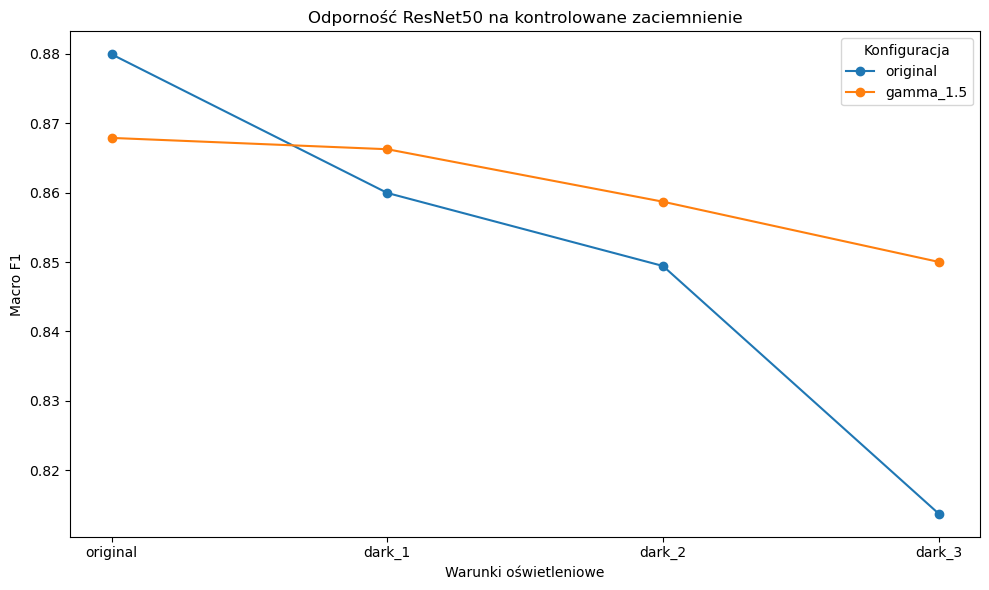

In [13]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)


for configuration in (
    final_lighting_results[
        "configuration"
    ].unique()
):

    subset = (
        final_lighting_results[
            final_lighting_results[
                "configuration"
            ]
            == configuration
        ]
    )

    subset = subset[
        subset[
            "variant"
        ].isin(
            [
                "original",
                "dark_1",
                "dark_2",
                "dark_3",
            ]
        )
    ]


    ax.plot(
        subset[
            "variant"
        ],
        subset[
            "macro_f1"
        ],
        marker="o",
        label=configuration,
    )


ax.set_title(
    "Odporność ResNet50 na kontrolowane zaciemnienie"
)

ax.set_xlabel(
    "Warunki oświetleniowe"
)

ax.set_ylabel(
    "Macro F1"
)

ax.legend(
    title="Konfiguracja"
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "01_final_dark_robustness_comparison.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 12. Końcowa ocena warunku oryginalnego

Porównanie wyników dla obrazów niezmodyfikowanych pozwala sprawdzić, czy wzrost odporności na zaciemnienie odbywa się kosztem standardowej skuteczności klasyfikacji.

In [14]:
original_results = (
    final_lighting_results[
        final_lighting_results[
            "variant"
        ] == "original"
    ]
    [
        [
            "configuration",
            "accuracy",
            "macro_precision",
            "macro_recall",
            "macro_f1",
        ]
    ]
)


display(
    original_results
)

,configuration,accuracy,macro_precision,macro_recall,macro_f1
0,original,0.901815,0.889437,0.887256,0.879895
4,gamma_1.5,0.895998,0.872612,0.878672,0.867861


## 13. Raport wyników dla poszczególnych klas

Dla końcowych konfiguracji oraz kontrolowanych warunków oświetleniowych przygotowywane są raporty wyników dla poszczególnych klas.

Raporty umożliwiają identyfikację klas najbardziej podatnych na silne zaciemnienie.

In [15]:
per_class_reports = {}


for result in detailed_results:

    configuration = result[
        "configuration"
    ]

    variant = result[
        "variant"
    ]


    report = pd.DataFrame(
        classification_report(
            result[
                "y_true"
            ],
            result[
                "y_pred"
            ],
            labels=list(
                range(
                    len(class_codes)
                )
            ),
            target_names=[
                idx_to_class[index]
                for index in range(
                    len(class_codes)
                )
            ],
            output_dict=True,
            zero_division=0,
        )
    ).T


    report = report.iloc[
        :len(class_codes)
    ].copy()


    report[
        "class_code"
    ] = report.index


    report[
        "configuration"
    ] = configuration


    report[
        "variant"
    ] = variant


    per_class_reports[
        f"{configuration}_{variant}"
    ] = report


per_class_results = pd.concat(
    per_class_reports.values(),
    ignore_index=True,
)


display(
    per_class_results.head()
)

,precision,recall,f1-score,support,class_code,configuration,variant
0,0.650000,0.780000,0.709091,50.0,A-1,original,original
1,1.000000,0.909091,0.952381,11.0,A-11,original,original
2,0.909091,1.000000,0.952381,10.0,A-11a,original,original
3,0.850000,0.809524,0.829268,21.0,A-12a,original,original
4,0.818182,0.818182,0.818182,11.0,A-14,original,original


In [16]:
per_class_results.to_csv(
    METRICS_DIR
    / "final_lighting_test_per_class.csv",
    index=False,
    encoding="utf-8-sig",
)

## 14. Największe zmiany skuteczności klas dla silnego zaciemnienia

Analizowane są klasy, dla których zastosowanie silnego zaciemnienia powoduje największą zmianę wartości F1.

In [17]:
class_comparison = []


for configuration in [
    "original",
    "gamma_1.5",
]:

    original_report = (
        per_class_results[
            (
                per_class_results[
                    "configuration"
                ]
                == configuration
            )
            &
            (
                per_class_results[
                    "variant"
                ]
                == "original"
            )
        ]
        [
            [
                "class_code",
                "f1-score",
            ]
        ]
        .rename(
            columns={
                "f1-score":
                    "original_f1"
            }
        )
    )


    dark3_report = (
        per_class_results[
            (
                per_class_results[
                    "configuration"
                ]
                == configuration
            )
            &
            (
                per_class_results[
                    "variant"
                ]
                == "dark_3"
            )
        ]
        [
            [
                "class_code",
                "f1-score",
            ]
        ]
        .rename(
            columns={
                "f1-score":
                    "dark3_f1"
            }
        )
    )


    comparison = (
        original_report
        .merge(
            dark3_report,
            on="class_code",
            how="inner",
        )
    )


    comparison[
        "f1_change"
    ] = (
        comparison[
            "dark3_f1"
        ]
        -
        comparison[
            "original_f1"
        ]
    )


    comparison[
        "configuration"
    ] = configuration


    class_comparison.append(
        comparison
    )


class_degradation = pd.concat(
    class_comparison,
    ignore_index=True,
)


display(
    class_degradation
    .sort_values(
        [
            "configuration",
            "f1_change",
        ]
    )
    .groupby(
        "configuration"
    )
    .head(15)
)

,class_code,original_f1,dark3_f1,f1_change,configuration
127,B-34,0.755556,0.507937,-0.247619,gamma_1.5
163,D-27,0.880000,0.645161,-0.234839,gamma_1.5
172,D-4b,1.000000,0.800000,-0.200000,gamma_1.5
167,D-40,0.952381,0.777778,-0.174603,gamma_1.5
130,B-42,0.903226,0.742857,-0.160369,gamma_1.5
113,A-6d,0.806202,0.654206,-0.151996,gamma_1.5
103,A-21,1.000000,0.857143,-0.142857,gamma_1.5
168,D-41,0.880000,0.761905,-0.118095,gamma_1.5
137,C-10,0.820202,0.707207,-0.112995,gamma_1.5
148,C-7,1.000000,0.888889,-0.111111,gamma_1.5


## 15. Zapis końcowego podsumowania


In [18]:
final_summary = {
    "experiment":
        "final_lighting_test",

    "test_samples":
        len(test_df),

    "number_of_classes":
        len(class_codes),

    "configurations":
        [
            configuration[
                "name"
            ]
            for configuration
            in CONFIGURATIONS
        ],

    "lighting_variants":
        LIGHTING_VARIANTS,

    "dark_variants":
        [
            "dark_1",
            "dark_2",
            "dark_3",
        ],

    "results":
        final_lighting_results.to_dict(
            orient="records"
        ),

    "dark_summary":
        final_lighting_comparison
        .reset_index()
        .to_dict(
            orient="records"
        ),
}


(
    METRICS_DIR
    / "final_lighting_test_summary.json"
).write_text(
    json.dumps(
        final_summary,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


print(
    json.dumps(
        final_summary,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "experiment": "final_lighting_test",
  "test_samples": 4298,
  "number_of_classes": 92,
  "configurations": [
    "original",
    "gamma_1.5"
  ],
  "lighting_variants": [
    "original",
    "dark_1",
    "dark_2",
    "dark_3"
  ],
  "dark_variants": [
    "dark_1",
    "dark_2",
    "dark_3"
  ],
  "results": [
    {
      "configuration": "original",
      "variant": "original",
      "factor": 1.0,
      "samples": 4298,
      "accuracy": 0.90181479758027,
      "macro_precision": 0.8894371984416014,
      "macro_recall": 0.887256398764739,
      "macro_f1": 0.8798947136065122,
      "inference_time_seconds": 326.52181949999976
    },
    {
      "configuration": "original",
      "variant": "dark_1",
      "factor": 0.7,
      "samples": 4298,
      "accuracy": 0.8873894834806887,
      "macro_precision": 0.8720887193043608,
      "macro_recall": 0.865052978850555,
      "macro_f1": 0.859937356694822,
      "inference_time_seconds": 366.31364299999996
    },
    {
      "conf